# <center>Assignment 2 2026</center>

<center>Author: Lewei Xu (23709058)</center>

## Part 1: Ensemble Learning for Heart Disease Prediction

In this task, we will compare a range of ensemble methods for predicting the presence of heart disease in patients.

We will use the **Heart Disease dataset** from the UC Irvine Machine Learning Repository, available at: [https://doi.org/10.24432/C52P4X](https://doi.org/10.24432/C52P4X).

### Step 1: Load, Explore and Preprocess Dataset

First, we will load the dataset from the downloaded .data file, assign appropriate column names, and explore the dataset. From the source website "Additional Variables Information", the variables included in this dataset are as follows:

| Variable | Type | Description |
|----------|------|-------------|
| `age` | Numeric | Age in years |
| `sex` | Categorical | 1 = male; 0 = female |
| `cp` | Categorical | Chest pain type (1 = typical angina, 2 = atypical angina, 3 = non-anginal pain, 4 = asymptomatic) |
| `trestbps` | Numeric | Resting blood pressure (mm Hg) |
| `chol` | Numeric | Serum cholesterol (mg/dl) |
| `fbs` | Categorical | Fasting blood sugar > 120 mg/dl (1 = true; 0 = false) |
| `restecg` | Categorical | Resting ECG results (0 = normal, 1 = ST-T wave abnormality, 2 = left ventricular hypertrophy) |
| `thalach` | Numeric | Maximum heart rate achieved |
| `exang` | Categorical | Exercise induced angina (1 = yes; 0 = no) |
| `oldpeak` | Numeric | ST depression induced by exercise relative to rest |
| `slope` | Categorical | Slope of peak exercise ST segment (1 = upsloping, 2 = flat, 3 = downsloping) |
| `ca` | Numeric | Number of major vessels (0–3) colored by fluoroscopy |
| `thal` | Categorical | Thalassemia (3 = normal, 6 = fixed defect, 7 = reversible defect) |
| `num` | Target | Diagnosis of heart disease (see note below) |

**Note on the target variable:** The UCI website describes `num` as binary (0 or 1), which is the raw measurement of whether any major vessel has greater than 50% diameter narrowing. However, the actual Cleveland data file contains integer values from 0 to 4, representing the *number* of major vessels with significant narrowing. Following the assignment specification, we will binarise the target: **0 = absence of heart disease**, **1 = presence of heart disease** (any value greater than 0).

In [36]:
import pandas as pd
import numpy as np

# Downloded dataset has no header rows, manually specify column names based on documentation
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

df = pd.read_csv('processed.cleveland.data', names=column_names, na_values='?')
df = df.dropna() # dropna to make sure adaboost works

print("Dataset Head:")
print(df.head())

Dataset Head:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  num  
0    3.0  0.0   6.0    0  
1    2.0  3.0   3.0    2  
2    2.0  2.0   7.0    1  
3    3.0  0.0   3.0    0  
4    1.0  0.0   3.0    0  


In [37]:
print(f"Dataset Shape: {df.shape}")
print(f"Number of examples (rows): {df.shape[0]}")
print(f"Number of columns (features + target): {df.shape[1]}")

features = df.drop(columns=['num'])

# Categorise features based on documentation
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

print(f"\nTotal number of features: {len(features.columns)}")
print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

print("\nOriginal value counts (0 = no disease, 1-4 = increasing severity):")
print(df['num'].value_counts().sort_index())

# Binarise target variable
df['num'] = (df['num'] > 0).astype(int)

print("\nBinarised target value counts:")
print(df['num'].value_counts().sort_index())

Dataset Shape: (297, 14)
Number of examples (rows): 297
Number of columns (features + target): 14

Total number of features: 13
Numeric features (6): ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
Categorical features (7): ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

Original value counts (0 = no disease, 1-4 = increasing severity):
num
0    160
1     54
2     35
3     35
4     13
Name: count, dtype: int64

Binarised target value counts:
num
0    160
1    137
Name: count, dtype: int64


There are 303 rows (examples) in the dataset. Each example represents a single patient record from the Cleveland Clinic Foundation, containing 13 measurements and a target variable indicating the presence of heart disease.

There are 14 columns in total. 13 features and 1 target feature. As specified above, there are 6 numeric features and 7 categorical features.

The target has been binarised where 0 indicates absense of disease, and 1 indicates presence of heart disease.

### Step 2: Split Dataset

Now that we have explored out dataset and done adequate preprocessing, we will now split our dataset: 80% for training and 20% for testing, with stratification.

In [38]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['num'])
y = df['num']

# Split dataset with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

Train samples: 237, Test samples: 60


### Step 3: Fit Decision Tree Classifier Baseline

We will now fit a Decision Tree classifier to use as a baseline and evaluate it's performance on the test set. We will use thsi baseline later to compare against ensemble learning.

In [39]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.75      0.73        32
           1       0.69      0.64      0.67        28

    accuracy                           0.70        60
   macro avg       0.70      0.70      0.70        60
weighted avg       0.70      0.70      0.70        60



### Step 4: Fit Random Forest Classifier and AdaBoost Classifier

We will also fit 2 additional models usin scikit-learn:
- A Random Forest classifier with 500 estimators.
- An AdaBoost classifier with 500 estimators.

In [40]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

ada = AdaBoostClassifier(n_estimators=500, random_state=42)
ada.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=500, random_state=42)

### Step 5: Combine Models in Soft Voting Classifier

Finally, we will combine the 2 models fitted in the previous step into a Voting Classifer with soft voting.

**Note:** The assignment specifies to *"combine your models from the previous steps"*, which is ambiguous as to whether the Decision Tree baseline should be included. Since Task 3 explicitly introduces the Decision Tree as *"a baseline"*, we interpret it as a reference model for comparison rather than a candidate for the ensemble, and exclude it accordingly. Furthermore, as a weak model, including it would cause voting dilution, pulling the soft voting probabilities away from the stronger Random Forest and AdaBoost classifiers and degrading overall performance.

In [41]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(estimators=[('rf', rf), ('ada', ada)], voting='soft')
voting.fit(X_train, y_train)

VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(n_estimators=500,
                                                     random_state=42)),
                             ('ada',
                              AdaBoostClassifier(n_estimators=500,
                                                 random_state=42))],
                 voting='soft')

### Step 6: Compare Model Performance

Now that all our models are fitted, let's compare the performance between the Decision Tree Classifier baseline, Random Forest Classifier, AdaBoost Classifier, and the Voting Classifer that combines all 3 previous models. We will create a table of precision, recall and F1 metrics for each model, and also display a confusino matrix for each model.

Decision Tree Performance: 
              precision    recall  f1-score   support

           0       0.71      0.75      0.73        32
           1       0.69      0.64      0.67        28

    accuracy                           0.70        60
   macro avg       0.70      0.70      0.70        60
weighted avg       0.70      0.70      0.70        60

Random Forest Performance: 
              precision    recall  f1-score   support

           0       0.85      0.91      0.88        32
           1       0.88      0.82      0.85        28

    accuracy                           0.87        60
   macro avg       0.87      0.86      0.87        60
weighted avg       0.87      0.87      0.87        60

AdaBoost Performance: 
              precision    recall  f1-score   support

           0       0.87      0.84      0.86        32
           1       0.83      0.86      0.84        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85      

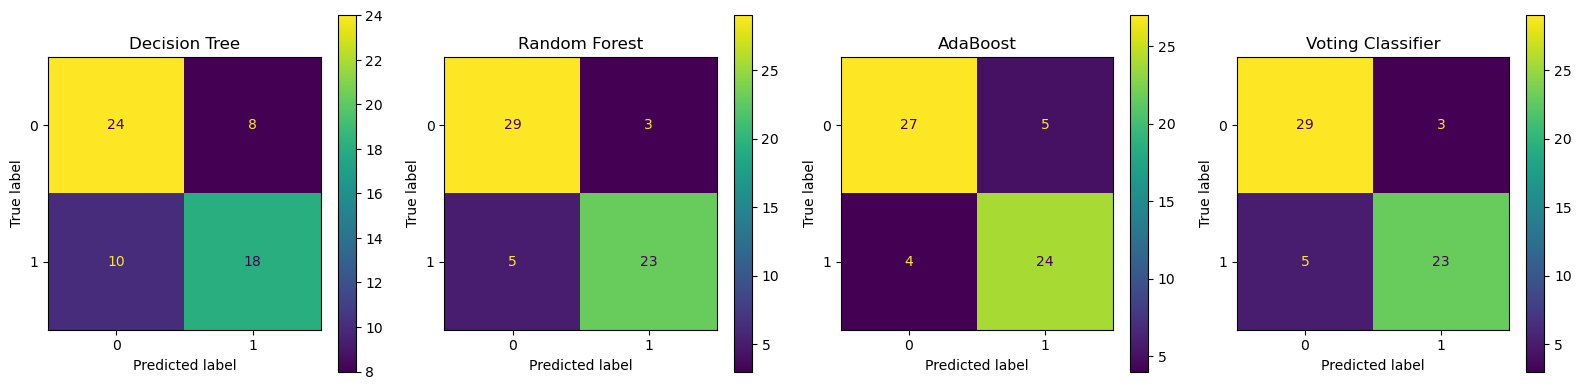

In [42]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = {'Decision Tree': dt, 'Random Forest': rf, 'AdaBoost': ada, 'Voting Classifier': voting}

# 6a: Precision, recall and F1 table
for name, model in models.items():
    print(f"{name} Performance: ")
    print(classification_report(y_test, model.predict(X_test)))

# 6b: Confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=ax)
    ax.set_title(name)
plt.tight_layout()
plt.show()

### Step 7: Explore Feature Importances of Random Forest Model

We will now plot the feature importances of the Random Forest model we fitted earlier to explore which features contribute most strongly to prediction.

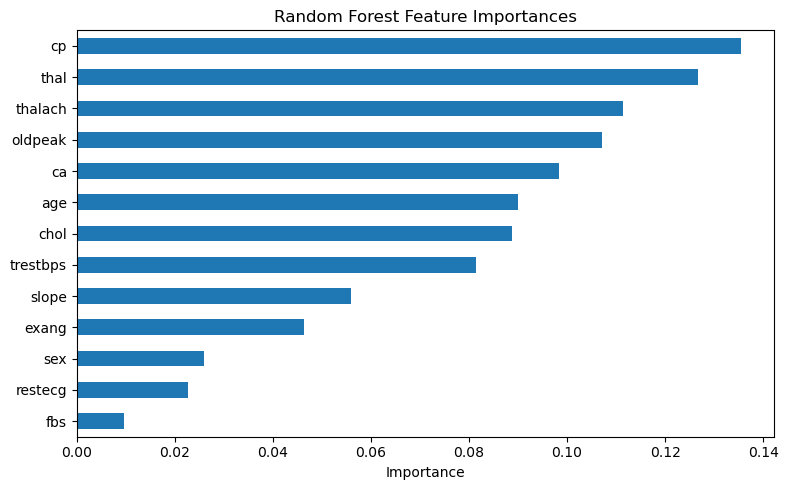

In [43]:
import pandas as pd

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

importances.plot(kind='barh', figsize=(8, 5), title='Random Forest Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

The three most important features are `cp` (chest pain type), `thal` (thalassemia), and `thalach` (maximum heart rate achieved), followed closely by `oldpeak` (ST depression) and `ca` (number of major vessels). Chest pain being the most important feature makes sense, after all, the body will try to generate pain signals if something is wrong in that area. Thalassemia is also a known cardiac condition directly associated with heart disease shown in various studies. On the other hand, we have `fbs` (fasting blood sugar) as the least important feature, which is actually surprising given the known link towards diabetes and cardiovascular disease. This may be a sign of bias as the dataset may only contain patients that are already undergoing cardiac investigation, resulting in all the value of `fbs` becoming less relevant.

### Step 8: Comments and Conclusion

(a) Model Comparison

The Random Forest and Voting Classifier both achieve the highest accuracy of 0.86, with identical results across all metrics. AdaBoost follows closely at 0.85, and the Decision Tree Classifier baseline performs the worst as expected at 0.7 accuracy. The fact that the Voting Classifier matches the Random Forest Classifier exactly rather than providing better performance suggests that the Random Forest Classifier is dominating the soft vote between itself and AdaBoost Classifier. This is because Random Forest Classifier's confidence in it's predictions are much higher than AdaBoost's consistently.We can verify this by comparing the mean maximum predicted probability of each model across the test set:

In [ ]:
rf_probs = rf.predict_proba(X_test)
ada_probs = ada.predict_proba(X_test)

print(f"Random Forest mean max probability: {round(rf_probs.max(axis=1).mean(), 3)}")
print(f"AdaBoost mean max probability:      {round(ada_probs.max(axis=1).mean(), 3)}")

Random Forest mean max probability: 0.795
AdaBoost mean max probability:      0.549


Here we can see that Random Forest's mean max probability is substantially higher than AdaBoost's by about 25%, resulting in Random Forest's vote dominating the majority of cases.

This outcome is mostly expected, as Random Forest is well suited to small datasets like this one (n < 500) where variance is the main source of error. AdaBoost's lower confidence is also expected, as it is a boosting method using weak learners, the confidence on estimates tend to be less decisive compared to an ensemble of trees.

(b) Bagging vs Boosting

Random Forest performs bagging which marginally outperforms AdaBoost which performs boosting. Bagging reduces variance by training many trees on random subsets of the data and averaging their predictions, while boosting reduces bias by correct the errors of previous weak learners. The bagging ensembled performed better in this case, indicating variance is the dominant source of error in this dataset. Although not entirely relevant, the Decision Tree Clasifier baseline's poor performance supports this, as a single tree is highly sensitive to the training examples. Due to the small number of examples, the single tree can overfit, which is exactly what we see in this case, and bagging works well to combat this issue.

(c) Ensemble Methods vs Decision Tree Baseline

The main advantages Ensemble Methods offer over the decision tree baseline is that they generalise better to unseen data by aggregating multiple models, reducing the impact of any single model's errors. Random Forest also provides feature importances as a byproduct of training, allowing us to see which features are the most important to the target class.

The main disadvantages of Ensemble Methods is that they are much more computationally expensive. After all, we are training 500 trees instead of just one. Ths resulting model is also much harder to interpret. A single decision tree can be fully visualised, but an ensemble of trees is difficult to visualise. This is especially important in the medical context where doctors need to understand how the model works to trust the model's reasoning. Although ensemble methods allow for much better performance in this case where the dataset size is small, in the medical setting, interpretability of the model may be more preferred.